# Функції активації. Проблема градієнта, що вибухає, і градієнта, що вимивається

## Функція активації – це математичне перетворення, яке застосовується до виходу нейрона перед передачею на наступний шар.

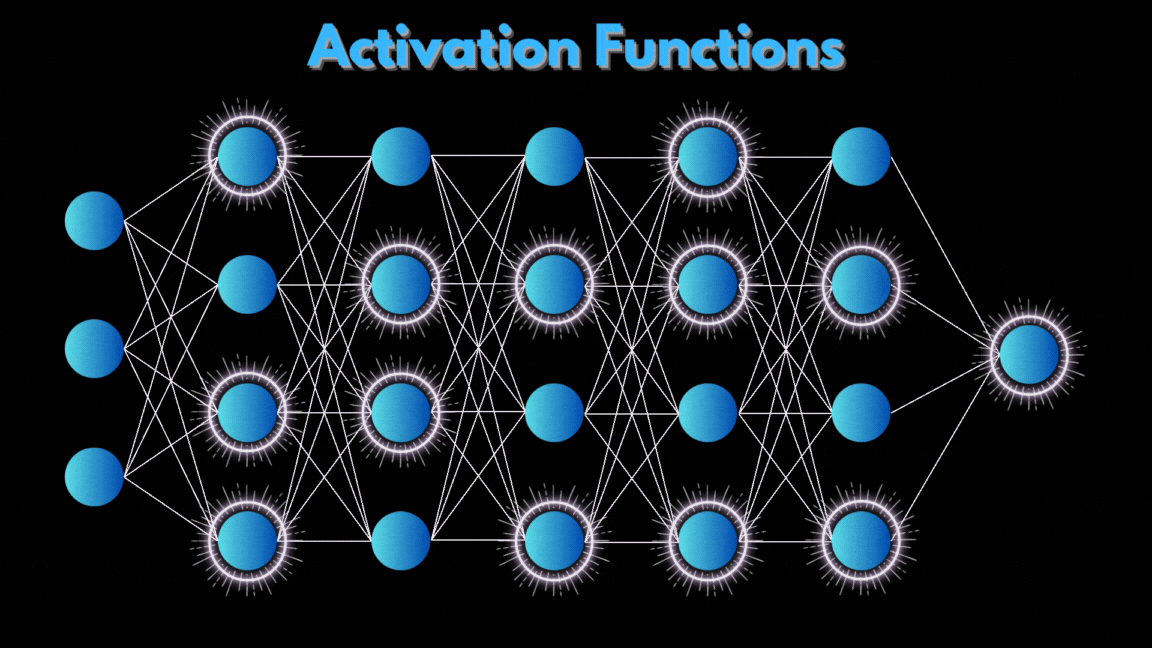

## Функції активації для вихідних шарів

## Sigmoid and Softmax

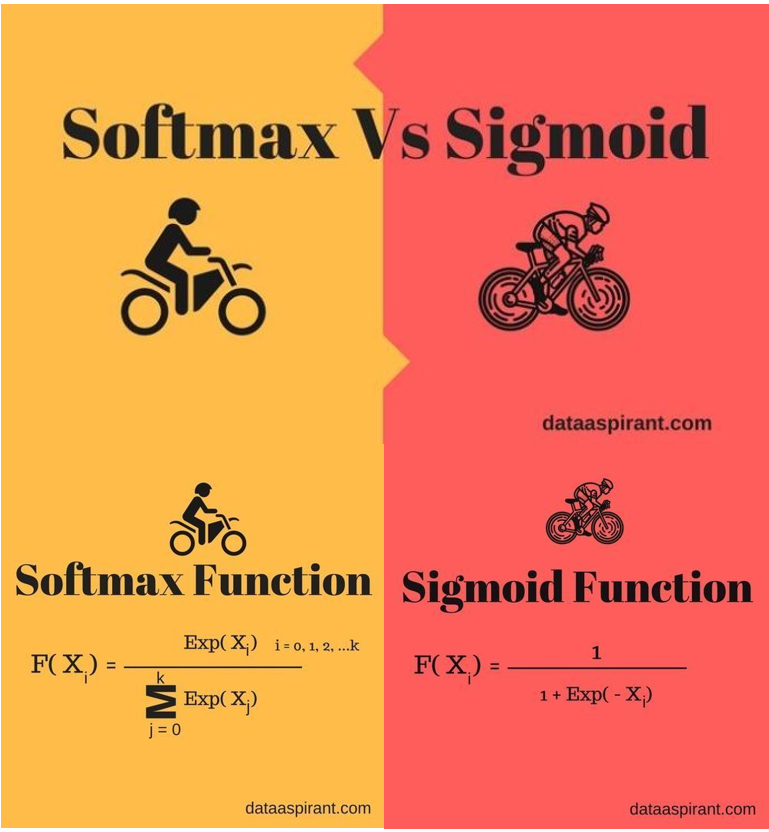

## Проблеми градієнта

## Вимивання градієнта (Vanishing Gradient)

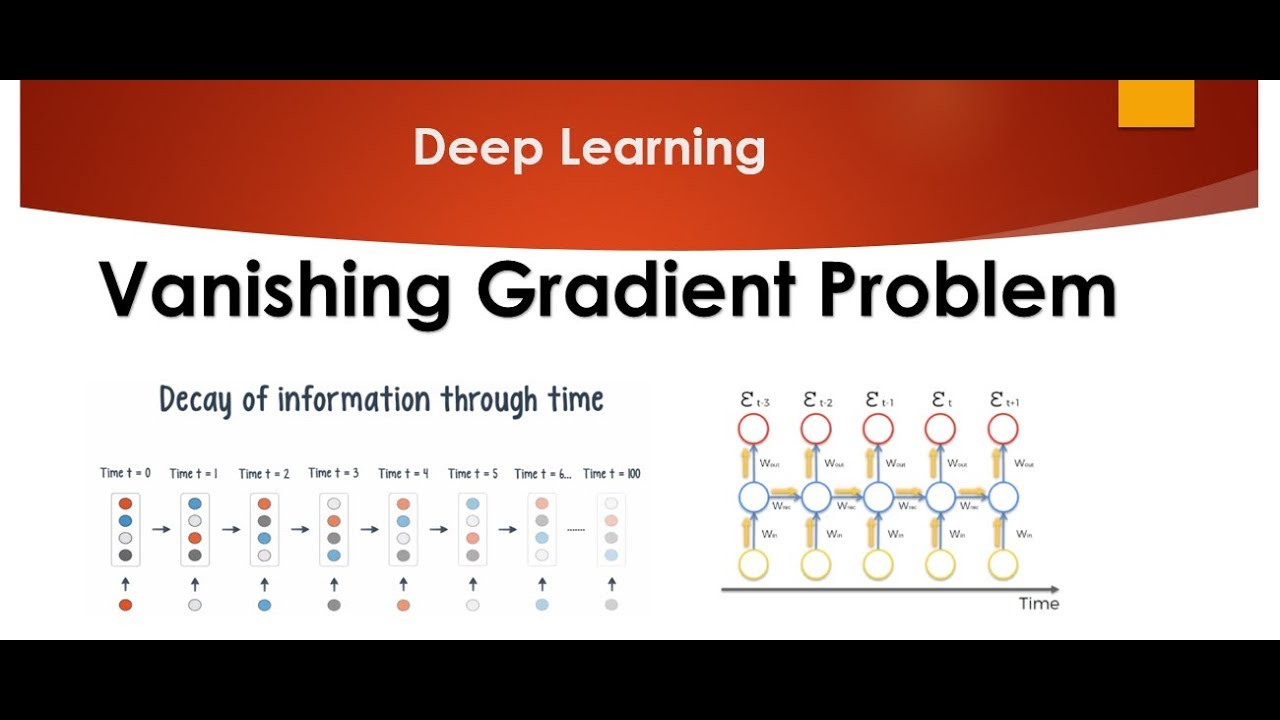

## Вибухання градієнта (Exploding Gradient)

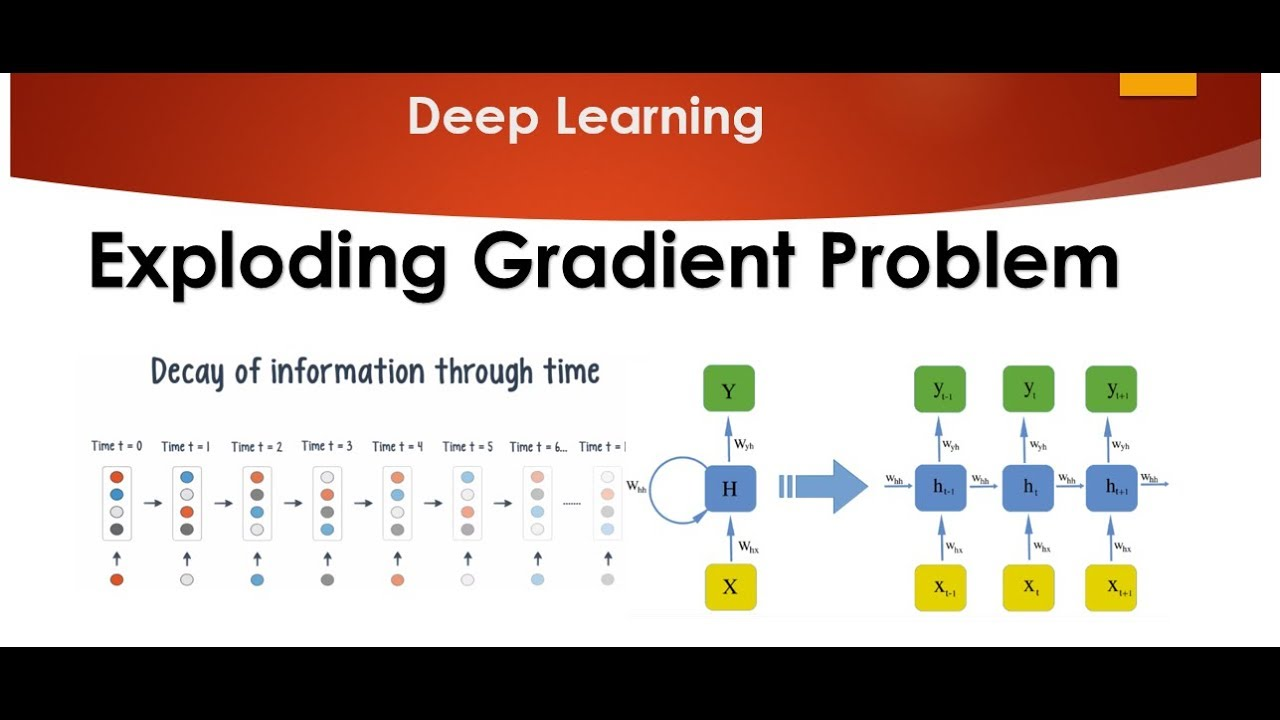

## Функції активації для прихованих шарів

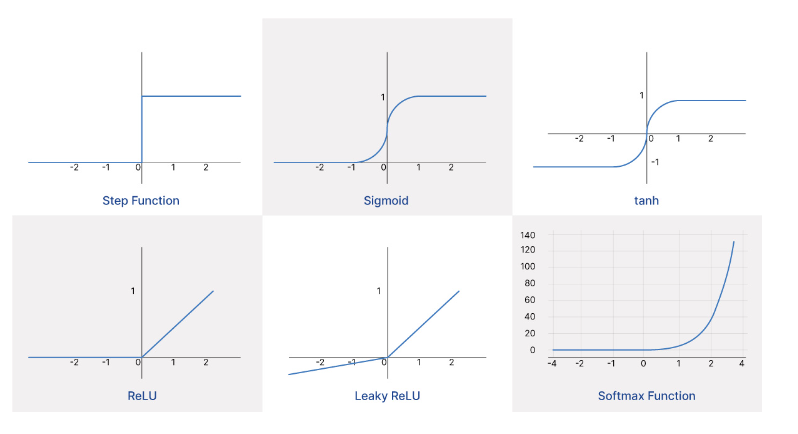

## Побудова нейронної мережі для передбачення вад серця

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim

df = pd.read_csv("heart.csv")

y = df['target'].values
X = df.drop('target', axis=1).values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

class HeartNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = HeartNN(input_dim=X_train.shape[1])

criterion = nn.BCEWithLogitsLoss()         
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 100
best_val_auc = 0.0
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs  = torch.sigmoid(val_logits)
        val_auc    = roc_auc_score(y_val, val_probs.numpy())
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = model.state_dict()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train loss: {loss.item():.4f} | Val AUC: {val_auc:.3f}")

model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_probs  = torch.sigmoid(test_logits).numpy()
    test_preds  = (test_probs > 0.5).astype(int)

print("Confusion matrix:\n", confusion_matrix(y_test, test_preds))
print(classification_report(y_test, test_preds, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))

Epoch 010 | Train loss: 0.4815 | Val AUC: 0.926
Epoch 020 | Train loss: 0.4017 | Val AUC: 0.938
Epoch 030 | Train loss: 0.3503 | Val AUC: 0.951
Epoch 040 | Train loss: 0.3134 | Val AUC: 0.958
Epoch 050 | Train loss: 0.2866 | Val AUC: 0.965
Epoch 060 | Train loss: 0.2731 | Val AUC: 0.970
Epoch 070 | Train loss: 0.2512 | Val AUC: 0.976
Epoch 080 | Train loss: 0.2322 | Val AUC: 0.980
Epoch 090 | Train loss: 0.2069 | Val AUC: 0.985
Epoch 100 | Train loss: 0.1953 | Val AUC: 0.986
Confusion matrix:
 [[67  8]
 [ 8 71]]
              precision    recall  f1-score   support

           0      0.893     0.893     0.893        75
           1      0.899     0.899     0.899        79

    accuracy                          0.896       154
   macro avg      0.896     0.896     0.896       154
weighted avg      0.896     0.896     0.896       154

ROC-AUC: 0.9569620253164557
